# TP2 (a completer) : Arbre de decision — *Pima Diabetes*

Remplacez chaque `...` et chaque `# TODO`. Le corrige
(`../notebooks/TP2_arbre_decision.ipynb`) applique la **meme demarche sur un
AUTRE dataset (Breast Cancer)** : la structure est identique, seules les donnees
et les colonnes changent : a vous d'adapter.

**Objectif.** Predire si une patiente est **diabetique** avec un arbre
**interpretable**, et evaluer en privilegiant le **rappel sur les cas diabetiques**.

In [1]:
# Cellule fournie : a executer telle quelle.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NAVY, ACCENT, GRAY = "#16284D", "#0EA5E9", "#5B6679"
RED = "#C0504D"
PALETTE = [ACCENT, NAVY, "#F79646", "#3FA45B", RED]
plt.rcParams.update({
    "figure.figsize": (7, 4.5), "font.size": 12,
    "axes.titlecolor": NAVY, "axes.titleweight": "bold",
    "axes.edgecolor": GRAY, "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.width", 120)
print("Environnement pret.")

Environnement pret.


## Etape 0 : charger les donnees (fournie)

In [2]:
from sklearn.datasets import fetch_openml
ds = fetch_openml(name="diabetes", version=1, as_frame=True)   # telecharge une fois puis cache
X = ds.data                                  # 8 mesures medicales (preg, plas, pres, ...)
y = (ds.target == "tested_positive").astype(int)
CLASSES = ["non_diabetique", "diabetique"]   # 0 = negatif, 1 = positif
print(X.shape, CLASSES)

(768, 8) ['non_diabetique', 'diabetique']


## 1. Exploration
**Consigne.** Affichez la repartition des classes (combien de diabetiques / non).

class
non_diabetique    500
diabetique        268
Name: count, dtype: int64


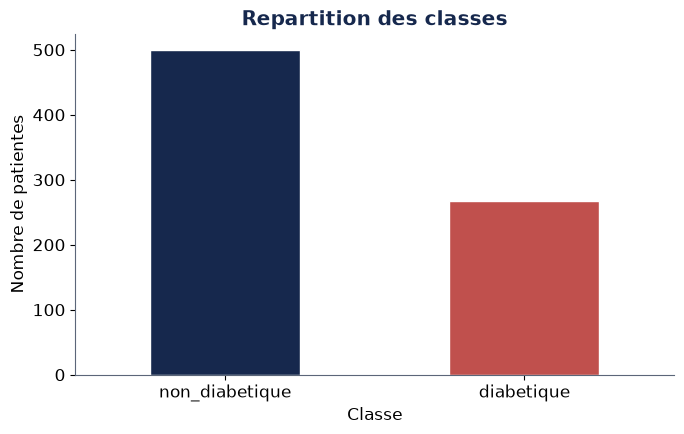

In [3]:
# Repartition de y (indice : value_counts + map vers CLASSES)
repartition = y.value_counts().rename(index=dict(enumerate(CLASSES)))
print(repartition)
repartition.plot(kind="bar", color=[PALETTE[1], RED], edgecolor="white")
plt.title("Repartition des classes")
plt.xlabel("Classe")
plt.ylabel("Nombre de patientes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 2. Modelisation
**Consigne.** Separez en train/test (25% test, `stratify=y`, `random_state=42`),
puis entrainez un `DecisionTreeClassifier` (`max_depth=3`, `min_samples_leaf=10`).

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

arbre = DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, random_state=42)
arbre.fit(X_train, y_train)
print("Arbre entrainé :", arbre)

Arbre entrainé : DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, random_state=42)


## 3. Evaluation
**Consigne.** Affichez l'accuracy train et test, le `classification_report`
(avec `target_names=CLASSES`) et la **matrice de confusion**. Commentez le
**rappel** de la classe `diabetique`.

Accuracy train : 0.783
Accuracy test  : 0.714
                precision    recall  f1-score   support

non_diabetique       0.75      0.84      0.79       125
    diabetique       0.62      0.48      0.54        67

      accuracy                           0.71       192
     macro avg       0.68      0.66      0.67       192
  weighted avg       0.70      0.71      0.70       192



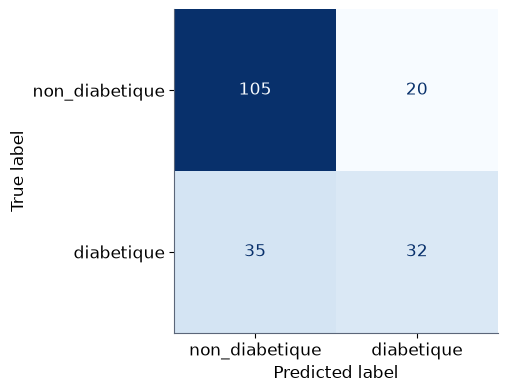

In [5]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

acc_train = arbre.score(X_train, y_train)
acc_test = arbre.score(X_test, y_test)
print(f"Accuracy train : {acc_train:.3f}")
print(f"Accuracy test  : {acc_test:.3f}")

y_pred = arbre.predict(X_test)
print(classification_report(y_test, y_pred, target_names=CLASSES))
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4.2))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, cmap="Blues", colorbar=False)
plt.show()

## 4. Visualisation
**Consigne.** Tracez l'arbre (`plot_tree`) puis l'**importance des variables**
(barres horizontales des `feature_importances_` non nulles).

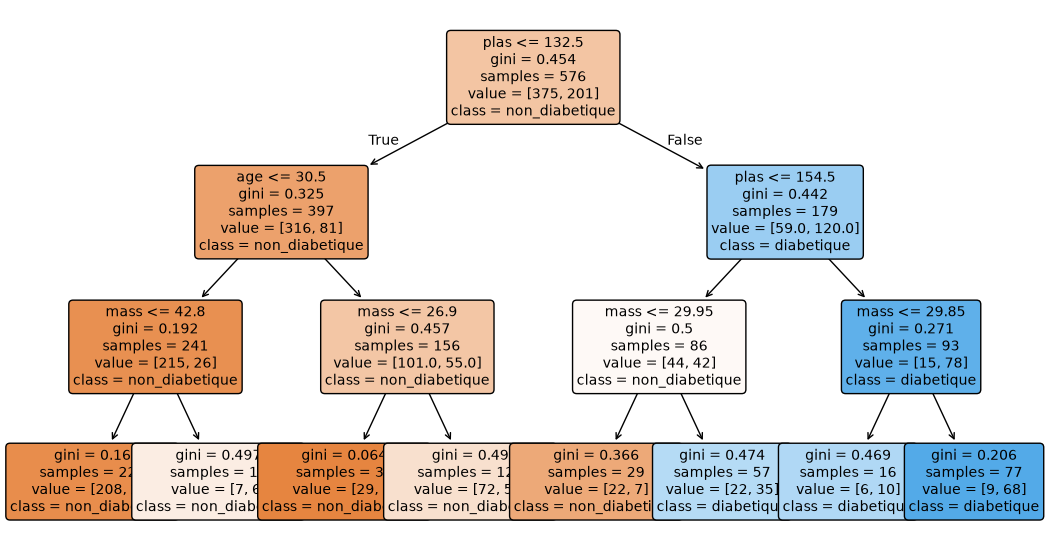

In [6]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(13, 7))
plot_tree(
    arbre,
    feature_names=X.columns,
    class_names=CLASSES,
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax,
)
plt.show()

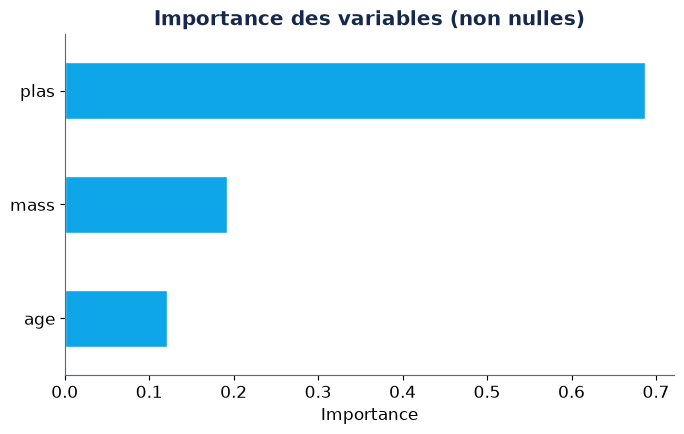

In [7]:
imp = pd.Series(arbre.feature_importances_, index=X.columns)
imp = imp[imp > 0].sort_values()
imp.plot(kind="barh", color=ACCENT, edgecolor="white")
plt.title("Importance des variables (non nulles)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 5. Prise de decision
**Consigne.** Sur 5 cas du test, affichez diagnostic reel, predit et
`predict_proba` de la classe diabetique.

In [8]:
ech = X_test.head(5)
pred = arbre.predict(ech)
proba_diab = arbre.predict_proba(ech)[:, 1]

comparatif = pd.DataFrame({
    "diagnostic_reel": [CLASSES[i] for i in y_test.loc[ech.index]],
    "diagnostic_predit": [CLASSES[i] for i in pred],
    "proba_diabetique": proba_diab.round(3),
}, index=ech.index)
comparatif

,diagnostic_reel,diagnostic_predit,proba_diabetique
635,diabetique,non_diabetique,0.429
698,non_diabetique,non_diabetique,0.088
637,non_diabetique,non_diabetique,0.088
402,diabetique,diabetique,0.614
425,diabetique,diabetique,0.883


## 6. XGBoost

Meme pipeline que les etapes precedentes (memes `X_train` / `X_test`),
mais avec **XGBoost** : plusieurs petits arbres qui s'enchainent pour
corriger leurs erreurs.

> **Prerequis** : `pip install xgboost` si besoin.
>
> Comparez avec l'arbre des etapes 2-5 : performance vs interpretabilite.

### 6.1 Modelisation
Entrainez un `XGBClassifier` (`n_estimators=100`, `max_depth=3`,
`learning_rate=0.1`, `min_child_weight=10`, `scale_pos_weight` pour
le desequilibre des classes, `random_state=42`).

In [ ]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    min_child_weight=10,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss",
)
xgb.fit(X_train, y_train)
print("XGBoost entraine.")
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

### 6.2 Evaluation
Accuracy train/test, `classification_report`, matrice de confusion.

In [ ]:
from sklearn.metrics import recall_score

acc_train_xgb = xgb.score(X_train, y_train)
acc_test_xgb = xgb.score(X_test, y_test)
print(f"Accuracy train : {acc_train_xgb:.3f}")
print(f"Accuracy test  : {acc_test_xgb:.3f}")

y_pred_xgb = xgb.predict(X_test)
print(classification_report(y_test, y_pred_xgb, target_names=CLASSES))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
fig, ax = plt.subplots(figsize=(5, 4.2))
ConfusionMatrixDisplay(cm_xgb, display_labels=CLASSES).plot(
    ax=ax, cmap="Blues", colorbar=False
)
plt.title("Matrice de confusion — XGBoost")
plt.show()

### 6.3 Comparaison arbre vs XGBoost
Tableau sur le **meme** jeu de test.

In [ ]:
recall_arbre = recall_score(y_test, y_pred, pos_label=1)
recall_xgb = recall_score(y_test, y_pred_xgb, pos_label=1)

comparaison = pd.DataFrame(
    {
        "accuracy_train": [acc_train, acc_train_xgb],
        "accuracy_test": [acc_test, acc_test_xgb],
        "recall_diabetique": [recall_arbre, recall_xgb],
    },
    index=["arbre", "xgboost"],
).round(3)
comparaison

### 6.4 Importance des variables
XGBoost n'a pas d'arbre unique lisible comme `plot_tree` : le modele
combine **100 petits arbres**. On visualise les importances.

In [ ]:
imp_xgb = pd.Series(xgb.feature_importances_, index=X.columns)
imp_xgb = imp_xgb[imp_xgb > 0].sort_values()
imp_xgb.plot(kind="barh", color=ACCENT, edgecolor="white")
plt.title("Importance des variables — XGBoost")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### 6.5 Prise de decision
Sur les memes 5 cas que l'etape 5 : arbre vs XGBoost.

In [ ]:
pred_xgb = xgb.predict(ech)
proba_diab_xgb = xgb.predict_proba(ech)[:, 1]

comparatif_xgb = pd.DataFrame(
    {
        "diagnostic_reel": [CLASSES[i] for i in y_test.loc[ech.index]],
        "pred_arbre": [CLASSES[i] for i in pred],
        "pred_xgboost": [CLASSES[i] for i in pred_xgb],
        "proba_diab_xgb": proba_diab_xgb.round(3),
    },
    index=ech.index,
)
comparatif_xgb

## 7. Bonus — effet de `max_depth` et surapprentissage

**Question.** Faites varier `max_depth` (2, 3, 6, `None`) : où commence le
surapprentissage ?

**Surapprentissage (overfitting)** : le modèle **mémorise** le train au lieu de
**généraliser** sur le test. Signe typique : accuracy **train** qui monte,
accuracy **test** qui stagne ou baisse → **écart train − test** qui s'élargit.

In [ ]:
depths = [2, 3, 6, None]
rows = []
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, min_samples_leaf=10, random_state=42)
    m.fit(X_train, y_train)
    acc_tr = m.score(X_train, y_train)
    acc_te = m.score(X_test, y_test)
    rows.append({
        "max_depth": d,
        "accuracy_train": round(acc_tr, 3),
        "accuracy_test": round(acc_te, 3),
        "ecart_train_test": round(acc_tr - acc_te, 3),
        "recall_diabetique": round(recall_score(y_test, m.predict(X_test), pos_label=1), 3),
        "nb_feuilles": m.get_n_leaves(),
    })

bonus = pd.DataFrame(rows)
bonus

fig, ax = plt.subplots(figsize=(7, 4.5))
x = bonus["max_depth"].astype(str)
ax.plot(x, bonus["accuracy_train"], "o-", color=NAVY, label="Train")
ax.plot(x, bonus["accuracy_test"], "s-", color=ACCENT, label="Test")
ax.set_xlabel("max_depth")
ax.set_ylabel("Accuracy")
ax.set_title("Train vs test selon max_depth")
ax.legend()
plt.tight_layout()
plt.show()

### Conclusion

| max_depth | Interprétation |
|-----------|----------------|
| **2** | Modèle **trop simple** (underfitting) : train et test bas, rappel diabétique faible (~30 %). Peu de surapprentissage (écart ~5 pp) mais performance insuffisante. |
| **3** | **Bon compromis** (choix du TP) : test ~71 %, rappel ~48 %, arbre lisible (8 feuilles). |
| **6** | **Début du surapprentissage** : train monte fort (+5 pp vs depth=3), test progresse moins ; **écart train − test maximal (~7,5 pp)**. Règles plus complexes (28 feuilles). |
| **None** | Arbre quasi illimité : train continue de monter (~83,5 %). Le test s'améliore encore grâce à `min_samples_leaf=10` qui limite les feuilles trop petites — sans cette contrainte, le surapprentissage serait bien plus violent. |

**Réponse.** Le surapprentissage **commence surtout à partir de `max_depth=6`** : l'accuracy train augmente nettement tandis que le test progresse moins vite et l'écart train − test s'élargit. Avec `max_depth=2`, c'est l'inverse (underfitting). **`max_depth=3`** reste le meilleur compromis entre performance, rappel et interprétabilité pour ce TP.

## A rendre
- Accuracy test + lecture de la matrice de confusion (arbre).
- Le rappel sur `diabetique` et pourquoi il est prioritaire ici.
- Les 2-3 variables les plus determinantes.
- **Section 6** : XGBoost fait-il mieux ? Compromis performance vs interpretabilite.
- **Section 7** : reponse au bonus `max_depth` et surapprentissage.